# Porject Summary
### The dataset of this project is a CSV file containing hand landmarks (e.g., x, y, z coordinates of keypoints) extracted from the HaGRID dataset using MediaPipe. The output will be a trained machine learning model capable of classifying hand gestures into predefined classes. 

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [36]:
df = pd.read_csv(r"C:\Users\Dell\Desktop\ml1-project\hand_landmarks_data .csv")
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [37]:
df.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21
count,25675.000000,25675.000000,2.567500e+04,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,...,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000
mean,201.958632,260.158527,1.272461e-07,202.517395,252.115322,-0.009465,202.862981,240.645966,-0.015946,203.025267,...,-0.024129,201.792374,227.455597,-0.033751,201.811275,227.802576,-0.032208,201.874802,227.807287,-0.028828
std,90.500333,76.533210,2.737932e-07,84.770933,75.384691,0.010376,80.412089,74.721921,0.013973,79.647588,...,0.015658,94.046497,77.231210,0.020453,93.664595,78.441253,0.020877,93.547017,79.963438,0.021136
min,-36.050926,45.722923,-2.029986e-06,7.184681,51.256840,-0.096630,25.114323,45.489950,-0.155846,23.446341,...,-0.201897,0.198635,20.146784,-0.286821,3.278137,32.158108,-0.286470,-4.537216,23.226204,-0.262047
25%,124.110329,205.815950,-5.243216e-08,130.535929,197.999625,-0.015199,136.711035,187.018583,-0.023020,138.905817,...,-0.030728,126.828913,172.720392,-0.042726,126.887403,172.345467,-0.041957,126.356627,172.083794,-0.039220
50%,199.667847,255.181793,1.497277e-07,199.979530,247.113892,-0.008737,200.092758,235.776978,-0.014231,200.482040,...,-0.020969,197.579865,221.781479,-0.029942,197.591736,222.381149,-0.028510,197.453270,222.485229,-0.025269
75%,266.428482,304.991663,2.989988e-07,261.147457,296.850769,-0.002783,255.876354,284.925993,-0.007134,254.622768,...,-0.013661,268.103920,273.190765,-0.019987,267.745743,274.196884,-0.017971,267.324657,275.805222,-0.014294
max,633.556020,781.674469,1.876254e-06,606.232386,751.869416,0.076365,598.541348,719.365010,0.094131,607.999801,...,0.031774,632.923029,779.419948,0.078105,638.134761,760.854103,0.104580,641.788521,760.554894,0.118668


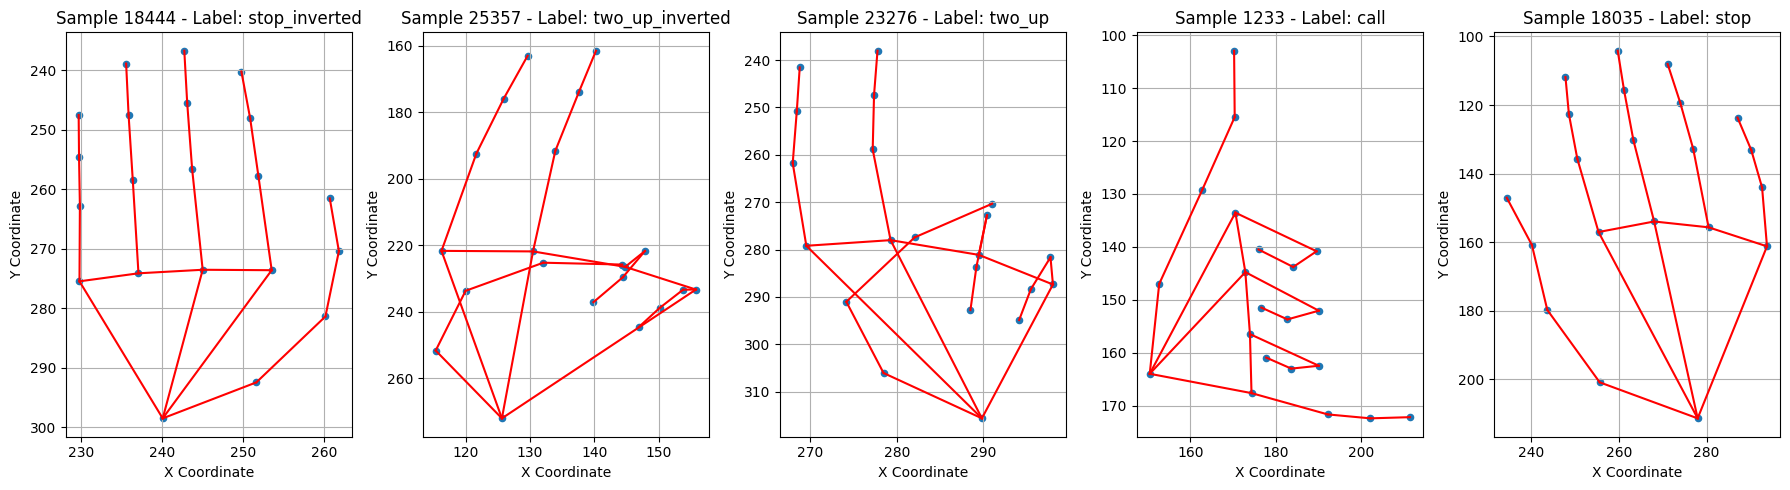

In [38]:
num_landmarks = 21

hand_connections = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (9, 10), (10, 11), (11, 12),
    (0, 9), (13, 14), (14, 15), (15, 16),
    (0, 17), (17, 18), (18, 19), (19, 20),
    (5, 9), (9, 13), (13, 17)
]

num_samples_to_plot = 5
samples_to_plot = df.sample(n=num_samples_to_plot)

plt.figure(figsize=(18, 5))

for i, (index, row) in enumerate(samples_to_plot.iterrows()):
    plt.subplot(1, num_samples_to_plot, i + 1)

    x_coords = []
    y_coords = []

    for j in range(1, num_landmarks + 1):
        x_coords.append(row[f'x{j}'])
        y_coords.append(row[f'y{j}'])

    plt.scatter(x_coords, y_coords, s=20)

    for connection in hand_connections:
        start_idx = connection[0]
        end_idx = connection[1]
        if start_idx < len(x_coords) and end_idx < len(x_coords):
            plt.plot(
                [x_coords[start_idx], x_coords[end_idx]],
                [y_coords[start_idx], y_coords[end_idx]],
                'r-'
            )

    plt.title(f'Sample {index} - Label: {row["label"]}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)

    plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## There is no major class imbalance that may affect the model performance

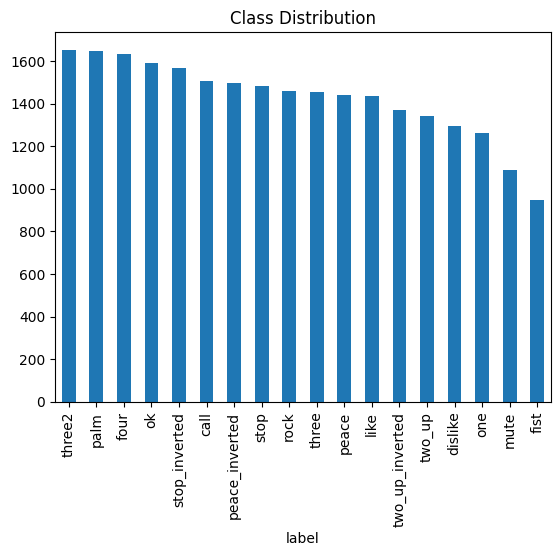

In [39]:
# checking for class imbalance
df['label'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

# Data Preprocessing
#### 1. recenter the hand landmarks (x,y) to make the origin the wrist point and divide all the landmarks by the mid-finger tip position.
#### 2. Split data into train test split

In [22]:
wrist_x = df['x1']
wrist_y = df['y1']

mid_finger_tip_x_recenter = (df['x13'] - wrist_x)
mid_finger_tip_y_recenter = (df['y13'] - wrist_y)

for j in range(1, 22):
    df[f'x{j}'] = df[f'x{j}'] - wrist_x
    df[f'y{j}'] = df[f'y{j}'] - wrist_y

    df[f'x{j}'] = df[f'x{j}'] / mid_finger_tip_x_recenter
    df[f'y{j}'] = df[f'y{j}'] / mid_finger_tip_y_recenter

In [23]:
features = df.drop('label', axis=1)
label = df['label']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.2, random_state=42)

# Model training

##### 1. Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf_search = GridSearchCV(estimator=rf, param_grid={'n_estimators': [100, 200, 250, 300]}, cv=3)
print("Starting GridSearchCV for Random Forest...")
rf_search.fit(X_train, y_train)
print("GridSearchCV for Random Forest completed.")
print(f"Best parameters for Random Forest: {rf_search.best_params_}")
print(f"Best cross-validation score for Random Forest: {rf_search.best_score_:.4f}")
rf = rf_search.best_estimator_
test_accuracy = rf.score(X_test, y_test)
print(f"Test accuracy of the best Random Forest model: {test_accuracy:.4f}")
y_pred_rf = rf.predict(X_test)

Starting GridSearchCV for Random Forest...
GridSearchCV for Random Forest completed.
Best parameters for Random Forest: {'n_estimators': 200}
Best cross-validation score for Random Forest: 0.9649
Test accuracy of the best Random Forest model: 0.9653


In [26]:
cl_rf = classification_report(y_test, y_pred_rf)
print(cl_rf)

                 precision    recall  f1-score   support

           call       0.98      0.99      0.99       287
        dislike       0.98      0.96      0.97       260
           fist       1.00      0.99      0.99       209
           four       0.96      0.91      0.94       325
           like       0.97      0.98      0.98       304
           mute       0.95      0.96      0.96       195
             ok       0.98      0.99      0.99       340
            one       0.96      0.95      0.95       248
           palm       0.92      0.96      0.94       317
          peace       0.94      0.95      0.95       276
 peace_inverted       0.99      0.94      0.96       307
           rock       0.99      0.98      0.99       290
           stop       0.93      0.96      0.94       293
  stop_inverted       0.97      0.97      0.97       309
          three       0.98      0.96      0.97       298
         three2       0.99      0.99      0.99       331
         two_up       0.95    

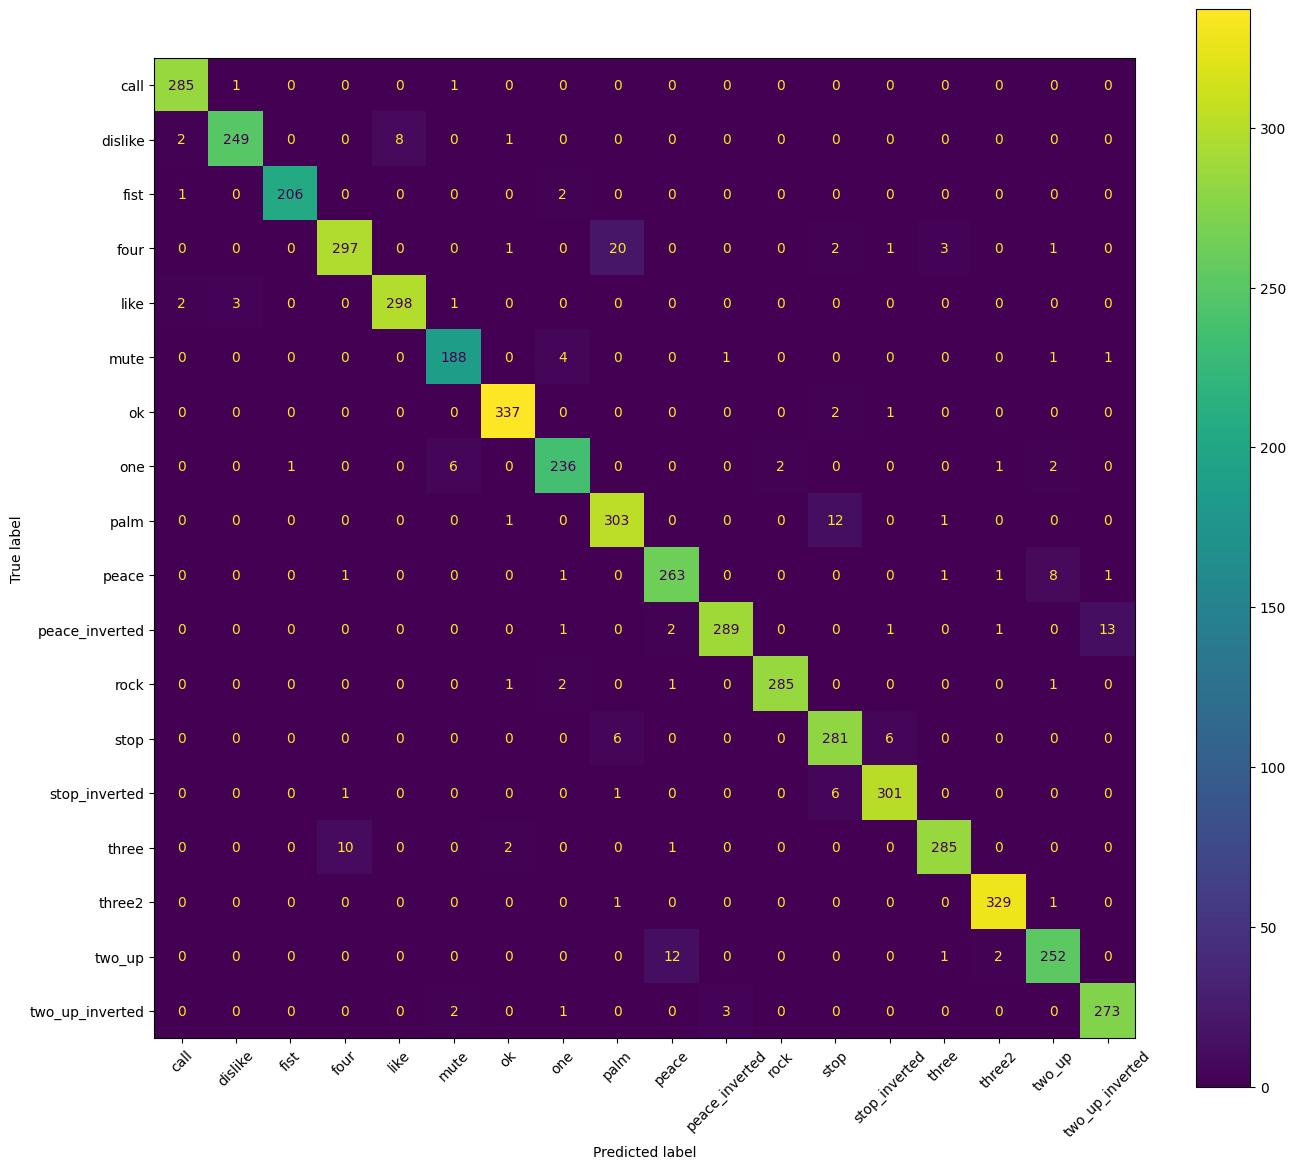

In [27]:
fig, ax = plt.subplots(figsize=(14, 12))

cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
cm_display.plot(ax=ax, colorbar=True, xticks_rotation=45)

plt.tight_layout()
plt.show()

##### 2. Support Vector Machine

In [28]:
param_grid = {
    'C': [10,50,80,100,130],
    'gamma': [0.01, 0.05, 0.1, 1],
    'kernel': ['rbf']
}
svm_model = SVC(random_state=42)
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv = 3,n_jobs=-1,verbose=1)
print("Starting GridSearchCV for SVM...")
grid_search.fit(X_train, y_train)
print("GridSearchCV for SVM completed.")
print(f"Best parameters for SVM: {grid_search.best_params_}")
print(f"Best cross-validation score for SVM: {grid_search.best_score_:.4f}")
best_svm_model = grid_search.best_estimator_
test_accuracy = best_svm_model.score(X_test, y_test)
print(f"Test accuracy of the best SVM model: {test_accuracy:.4f}")
svm_predict = best_svm_model.predict(X_test)

Starting GridSearchCV for SVM...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
GridSearchCV for SVM completed.
Best parameters for SVM: {'C': 130, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score for SVM: 0.9451
Test accuracy of the best SVM model: 0.9509


In [29]:
svm_report = classification_report(y_test, svm_predict)
print(svm_report)

                 precision    recall  f1-score   support

           call       0.99      0.94      0.97       287
        dislike       0.99      0.93      0.96       260
           fist       1.00      0.99      0.99       209
           four       0.96      0.93      0.95       325
           like       0.96      0.96      0.96       304
           mute       0.96      0.98      0.97       195
             ok       0.99      0.98      0.98       340
            one       0.98      0.91      0.94       248
           palm       0.97      0.97      0.97       317
          peace       0.96      0.93      0.95       276
 peace_inverted       0.99      0.98      0.98       307
           rock       1.00      0.97      0.98       290
           stop       0.94      0.89      0.92       293
  stop_inverted       0.66      0.97      0.79       309
          three       0.99      0.92      0.95       298
         three2       0.99      0.98      0.98       331
         two_up       0.98    

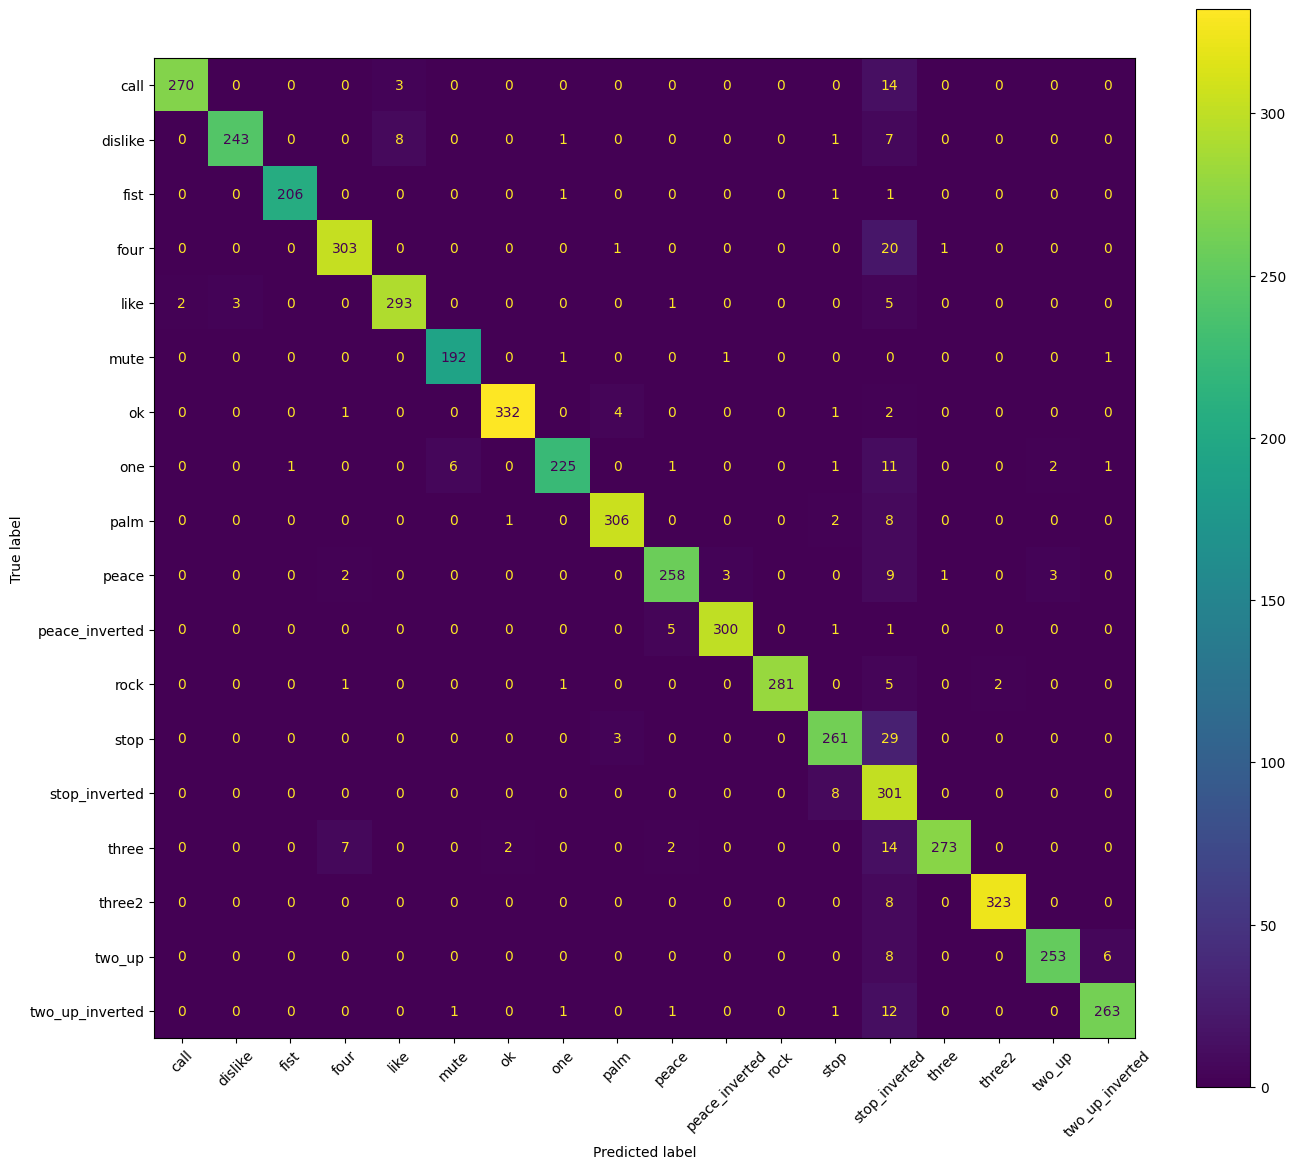

In [30]:
fig, ax = plt.subplots(figsize=(14, 12))

cm = confusion_matrix(y_test, svm_predict, labels=best_svm_model.classes_)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_svm_model.classes_)
cm_display.plot(ax=ax, colorbar=True, xticks_rotation=45)

plt.tight_layout()
plt.show()

##### 3. AdaBoost

In [31]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
param_grids={
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.1, 0.5],
    'estimator__max_depth': [1, 3, 5]
}
ab = AdaBoostClassifier(estimator= dt, random_state=42)
ab_search = GridSearchCV(estimator=ab, param_grid=param_grids, cv=3, n_jobs=-1, verbose=1)
print("Starting GridSearchCV for AdaBoost...")
ab_search.fit(X_train, y_train)
print("GridSearchCV for AdaBoost completed.")
print(f"Best parameters for AdaBoost: {ab_search.best_params_}")
print(f"Best cross-validation score for AdaBoost: {ab_search.best_score_:.4f}")
ab = ab_search.best_estimator_
ab_predict = ab.predict(X_test)

Starting GridSearchCV for AdaBoost...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
GridSearchCV for AdaBoost completed.
Best parameters for AdaBoost: {'estimator__max_depth': 5, 'learning_rate': 0.5, 'n_estimators': 500}
Best cross-validation score for AdaBoost: 0.9567


In [32]:
cr = classification_report(y_test, ab_predict)
print(cr)

                 precision    recall  f1-score   support

           call       0.99      0.97      0.98       287
        dislike       0.98      0.95      0.97       260
           fist       0.99      0.99      0.99       209
           four       0.97      0.94      0.95       325
           like       0.96      0.99      0.98       304
           mute       0.94      0.96      0.95       195
             ok       0.99      0.99      0.99       340
            one       0.95      0.94      0.95       248
           palm       0.91      0.95      0.93       317
          peace       0.87      0.86      0.87       276
 peace_inverted       0.90      0.96      0.93       307
           rock       0.99      0.99      0.99       290
           stop       0.90      0.95      0.92       293
  stop_inverted       0.98      0.95      0.97       309
          three       0.99      0.96      0.97       298
         three2       0.99      0.97      0.98       331
         two_up       0.85    

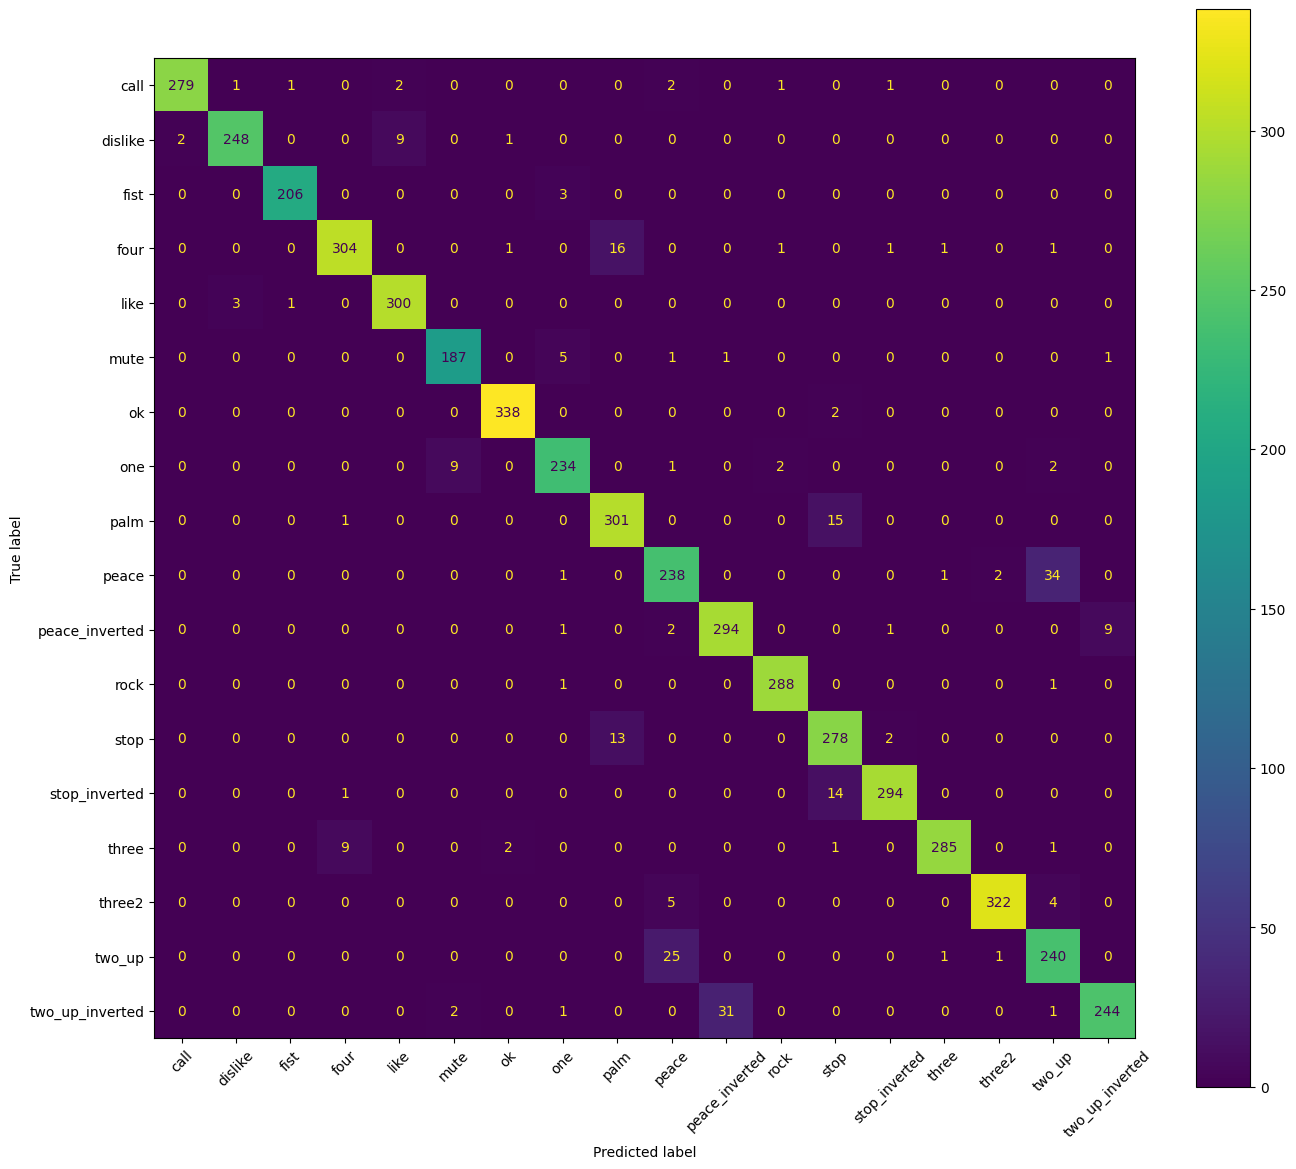

In [33]:
fig, ax = plt.subplots(figsize=(14, 12))

cm_ab = confusion_matrix(y_test, ab_predict, labels=ab.classes_)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_ab, display_labels=ab.classes_)
cm_display.plot(ax=ax, colorbar=True, xticks_rotation=45)

plt.tight_layout()
plt.show()

In [34]:
# save the best model
import joblib
joblib.dump(rf, 'random_forest_model.pkl')

['random_forest_model.pkl']

# Conclusion

#### In this notebook, three models have been trained. Random forset classifier model achieved the hightest f1 score of 97%. SVM and AdaBoost both socred f1 score of 95%. 